In [1]:
import pandas as pd
import pathlib as pl
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
root_path = pl.Path.cwd().parent.parent
data_path = root_path / "data" 

In [3]:
data = pd.read_csv(data_path /"Intermed" / "googleplaystore_clean.csv")
review_data = pd.read_csv(data_path /"intermed" / "googleplaystore_user_reviews_clean.csv")

In [4]:
data.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Days_Since_Update
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,213
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000.0,Free,0.0,Everyone,Art & Design,2018-01-15,2.0.0,4.0.3 and up,205
2,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000.0,Free,0.0,Everyone,Pretend Play,2018-01-15,2.0.0,4.0.3 and up,205
3,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,7
4,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,61


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9339 entries, 0 to 9338
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         9339 non-null   int64  
 1   App                9339 non-null   str    
 2   Category           9339 non-null   str    
 3   Rating             9339 non-null   float64
 4   Reviews            9339 non-null   int64  
 5   Size               9339 non-null   str    
 6   Installs           9339 non-null   float64
 7   Type               9339 non-null   str    
 8   Price              9339 non-null   float64
 9   Content Rating     9339 non-null   str    
 10  Genres             9339 non-null   str    
 11  Last Updated       9339 non-null   str    
 12  Current Ver        9335 non-null   str    
 13  Android Ver        9337 non-null   str    
 14  Days_Since_Update  9339 non-null   int64  
dtypes: float64(3), int64(3), str(9)
memory usage: 1.1 MB


In [6]:
display(review_data.info())
display(review_data.head())

<class 'pandas.DataFrame'>
RangeIndex: 29692 entries, 0 to 29691
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     29692 non-null  str    
 1   Translated_Review       29692 non-null  str    
 2   Sentiment               29692 non-null  str    
 3   Sentiment_Polarity      29692 non-null  float64
 4   Sentiment_Subjectivity  29692 non-null  float64
dtypes: float64(2), str(3)
memory usage: 1.1 MB


None

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
3,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
4,10 Best Foods for You,Best way,Positive,1.00,0.300000


In [7]:
data.Price.describe()

count    9339.000000
mean        0.942797
std        15.800217
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       400.000000
Name: Price, dtype: float64

In [8]:
notas_free = data[data['Type'] == 'Free']['Rating'].dropna()
notas_paid = data[data['Type'] == 'Paid']['Rating'].dropna()

In [9]:
import scipy.stats as stats


stat_levene, p_levene = stats.levene(notas_free, notas_paid)
print(f"P-value do teste de Levene: {p_levene:.4f}")

if p_levene > 0.05:
    print("Variâncias Iguais: Usando Teste T de Student padrão.")
    t_stat, p_final = stats.ttest_ind(notas_paid, notas_free, equal_var=True, alternative='greater')
    df = len(notas_paid) + len(notas_free) - 2
else:
    print("Variâncias Diferentes: Usando Teste t de Welch.")

    t_stat, p_final = stats.ttest_ind(notas_paid, notas_free, equal_var=False, alternative='greater')
    

    v1, v2 = notas_paid.var(), notas_free.var()
    n1, n2 = len(notas_paid), len(notas_free)
    df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))


t_critico = stats.t.ppf(1 - 0.05, df)

print("-" * 30)
print(f"Estatística t calculada: {t_stat:.4f}")
print(f"Valor Crítico t (limite): {t_critico:.4f}")
print(f"P-value Final: {p_final:.4f}")
print("-" * 30)

if t_stat > t_critico:
    print("A estatística t caiu na REGIÃO DE REJEIÇÃO.")
    print("Conclusão: Apps pagos têm avaliações significativamente maiores.")
else:
    print("A estatística t caiu na REGIÃO DE ACEITAÇÃO.")
    print("Conclusão: Não há evidências de que apps pagos avaliam melhor.")

P-value do teste de Levene: 0.3856
Variâncias Iguais: Usando Teste T de Student padrão.
------------------------------
Estatística t calculada: 4.0937
Valor Crítico t (limite): 1.6450
P-value Final: 0.0000
------------------------------
A estatística t caiu na REGIÃO DE REJEIÇÃO.
Conclusão: Apps pagos têm avaliações significativamente maiores.


/var/folders/cq/5nd0n3jx7zlbj9vw7ljftrpc0000gn/T/ipykernel_58627/597071580.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Type', y='Rating', width=0.5, ax=ax[0], palette='Set2')


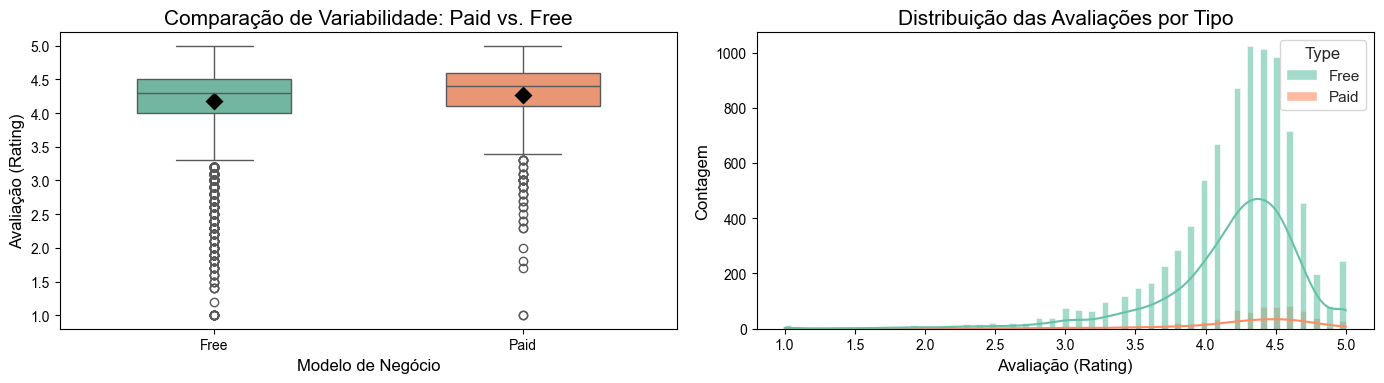

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.set_theme(style="whitegrid")

sns.boxplot(data=data, x='Type', y='Rating', width=0.5, ax=ax[0], palette='Set2')
sns.pointplot(data=data, x='Type', y='Rating', color='black', 
              markers='D', linestyles='', errorbar=None, ax=ax[0])

ax[0].set_title('Comparação de Variabilidade: Paid vs. Free', fontsize=15)
ax[0].set_xlabel('Modelo de Negócio', fontsize=12)
ax[0].set_ylabel('Avaliação (Rating)', fontsize=12)



sns.histplot(data=data, x='Rating', hue='Type', kde=True, palette='Set2', ax=ax[1], alpha=0.6)

ax[1].set_title('Distribuição das Avaliações por Tipo', fontsize=15)
ax[1].set_xlabel('Avaliação (Rating)', fontsize=12)
ax[1].set_ylabel('Contagem', fontsize=12)

plt.tight_layout()
plt.show()

In [11]:
review_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 29692 entries, 0 to 29691
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     29692 non-null  str    
 1   Translated_Review       29692 non-null  str    
 2   Sentiment               29692 non-null  str    
 3   Sentiment_Polarity      29692 non-null  float64
 4   Sentiment_Subjectivity  29692 non-null  float64
dtypes: float64(2), str(3)
memory usage: 1.1 MB


In [12]:
grouped_review_data = review_data.groupby(["App"]).agg({"Sentiment_Polarity":"count"}).sort_values("Sentiment_Polarity",ascending=False)

grouped_review_data = grouped_review_data.rename(columns={"Sentiment_Polarity":"Count_Sentiment_Polarity"})
grouped_review_data.head()

,Count_Sentiment_Polarity
App,
Facebook,130
Episode - Choose Your Story,124
Angry Birds Classic,107
Family Locator - GPS Tracker,105
Google Photos,101


In [13]:
grouped_review_data = review_data.groupby(["App"]).agg({"Sentiment_Polarity":"mean"}).sort_values("Sentiment_Polarity",ascending=False)

grouped_review_data = grouped_review_data.rename(columns={"Sentiment_Polarity":"Mean_Sentiment_Polarity"})
grouped_review_data.head()

,Mean_Sentiment_Polarity
App,
HomeWork,1.000000
Google Slides,0.933333
Daily Workouts - Exercise Fitness Routine Trainer,0.800000
Bed Time Fan - White Noise Sleep Sounds,0.781250
Cameringo Lite. Filters Camera,0.770269


In [14]:
merged_data = pd.merge(data, grouped_review_data, on="App", how="inner")
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               1156 non-null   int64  
 1   App                      1156 non-null   str    
 2   Category                 1156 non-null   str    
 3   Rating                   1156 non-null   float64
 4   Reviews                  1156 non-null   int64  
 5   Size                     1156 non-null   str    
 6   Installs                 1156 non-null   float64
 7   Type                     1156 non-null   str    
 8   Price                    1156 non-null   float64
 9   Content Rating           1156 non-null   str    
 10  Genres                   1156 non-null   str    
 11  Last Updated             1156 non-null   str    
 12  Current Ver              1156 non-null   str    
 13  Android Ver              1156 non-null   str    
 14  Days_Since_Update        1156 non-n

In [15]:
merged_data["Type"].value_counts()

Type
Free    1142
Paid      14
Name: count, dtype: int64

In [16]:


sentimento_free = merged_data[merged_data['Type'] == 'Free']['Mean_Sentiment_Polarity'].dropna()
sentimento_paid = merged_data[merged_data['Type'] == 'Paid']['Mean_Sentiment_Polarity'].dropna()

stat, p_levene = stats.levene(sentimento_free, sentimento_paid)
print(f"P-value Levene (Sentimento): {p_levene}")

t_stat, p_final = stats.ttest_ind(sentimento_free, sentimento_paid, equal_var=(p_levene > 0.05))

print(f"P-value Final (Sentimento): {p_final}")

P-value Levene (Sentimento): 0.05619872447315314
P-value Final (Sentimento): 0.7604640032211081


In [17]:
resume_main = data.groupby("Type").agg({
    "Rating":"mean",
    "App":"count"
})
display(resume_main)

,Rating,App
Type,,
Free,4.187097,8657
Paid,4.270821,682


In [18]:
resume = merged_data.groupby(["Type"]).agg({
    "Mean_Sentiment_Polarity":"mean",
    "App":"count"
    }).rename(columns={
        "App": "Total Apps",
        "Rating": "Rating"
        }).sort_values("Mean_Sentiment_Polarity",ascending=False)
display(resume.head())


,Mean_Sentiment_Polarity,Total Apps
Type,,
Free,0.183450,1142
Paid,0.170795,14


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Days_Since_Update
424,476,"Moco+ - Chat, Meet People",DATING,4.2,1545,Varies with device,10000.0,Paid,3.99,Mature 17+,Dating,2018-06-19,2.6.139,4.1 and up,50
425,477,Calculator,DATING,2.6,57,6.2M,1000.0,Paid,6.99,Everyone,Dating,2017-10-25,1.1.6,4.0 and up,287
426,481,AMBW Dating App: Asian Men Black Women Interra...,DATING,3.5,2,17M,100.0,Paid,7.99,Mature 17+,Dating,2017-01-21,1.0.1,4.0 and up,564
499,571,"Moco+ - Chat, Meet People",DATING,4.2,1546,Varies with device,10000.0,Paid,3.99,Mature 17+,Dating,2018-06-19,2.6.139,4.1 and up,50
717,851,Sago Mini Hat Maker,EDUCATION,4.9,11,63M,1000.0,Paid,3.99,Everyone,Education,2017-07-24,1.0,4.0.3 and up,380


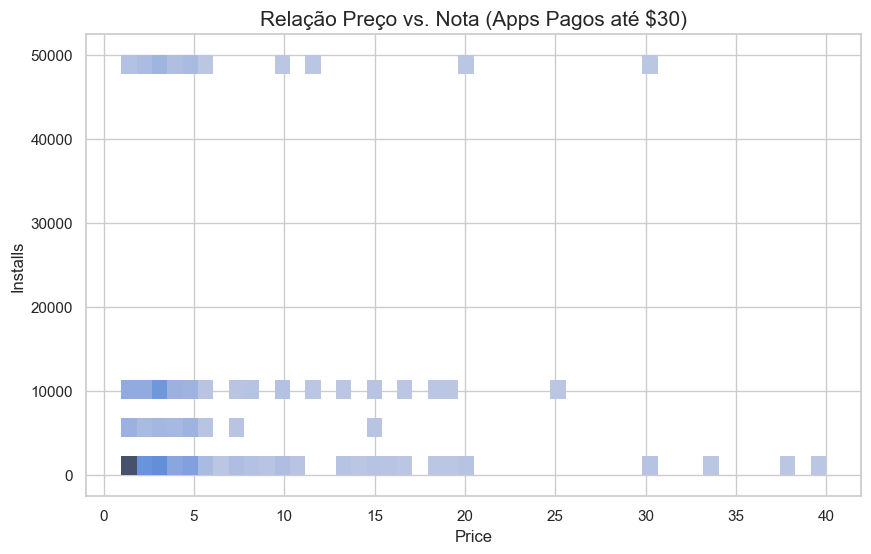

In [19]:

data_normal_price = data[(data['Price'] < 50) & (data['Type'] == 'Paid') & (data["Installs"]<60000)]
display(data_normal_price.head())
plt.figure(figsize=(10, 6))
sns.histplot(data=data_normal_price, x="Price",y="Installs")

plt.title('Relação Preço vs. Nota (Apps Pagos até $30)', fontsize=15)
plt.show()

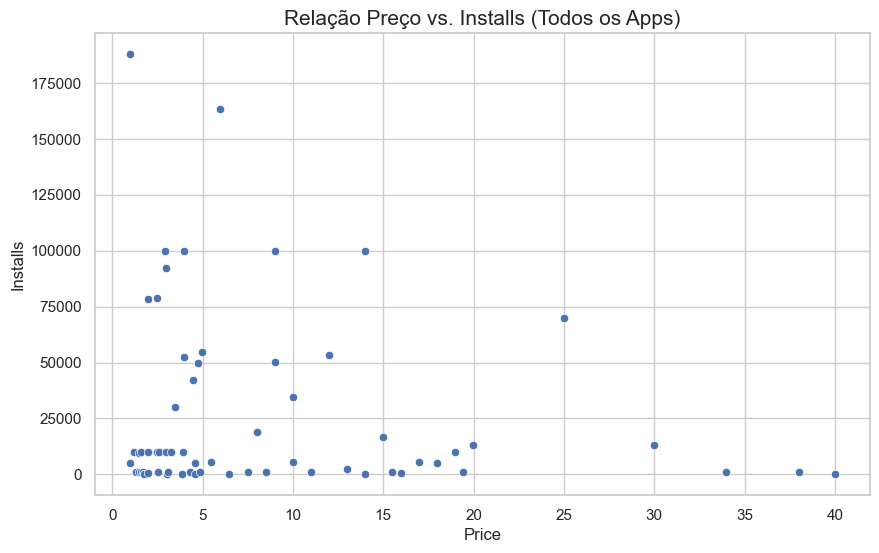

<Axes: xlabel='Price', ylabel='Count'>

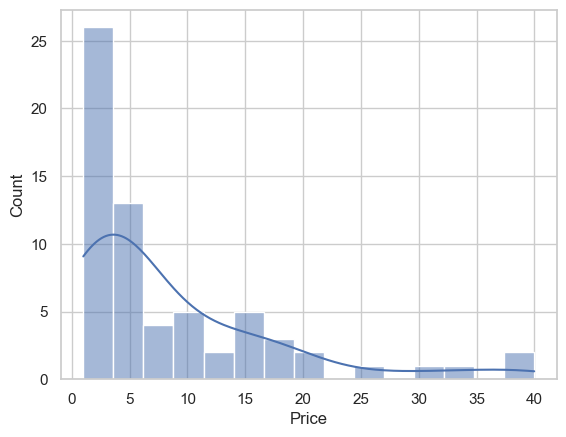

In [48]:

grouped_price = data.groupby("Price").agg({"Installs": "mean","App":"count"}).reset_index()
grouped_price = grouped_price[(grouped_price['Price'] < 50) & (grouped_price['Installs'] < 1000000)]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=grouped_price, x="Price", y="Installs")
plt.title('Relação Preço vs. Installs (Todos os Apps)', fontsize=15)
plt.show()
sns.histplot(data=grouped_price["Price"],bins=15,log_scale=False,kde=True)


In [21]:
category_Type_data = data.groupby(["Category","Type"]).agg({
    "Installs":"sum"
})

Genres_Type_data= data.groupby(["Genres","Type"]).agg({
    "Installs":"sum"
})

/var/folders/cq/5nd0n3jx7zlbj9vw7ljftrpc0000gn/T/ipykernel_58627/3073100502.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cat['Share_Paid'], y=top_cat.index, palette='magma', ax=ax[0])
/var/folders/cq/5nd0n3jx7zlbj9vw7ljftrpc0000gn/T/ipykernel_58627/3073100502.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_gen['Share_Paid'], y=top_gen.index, palette='magma', ax=ax[1])


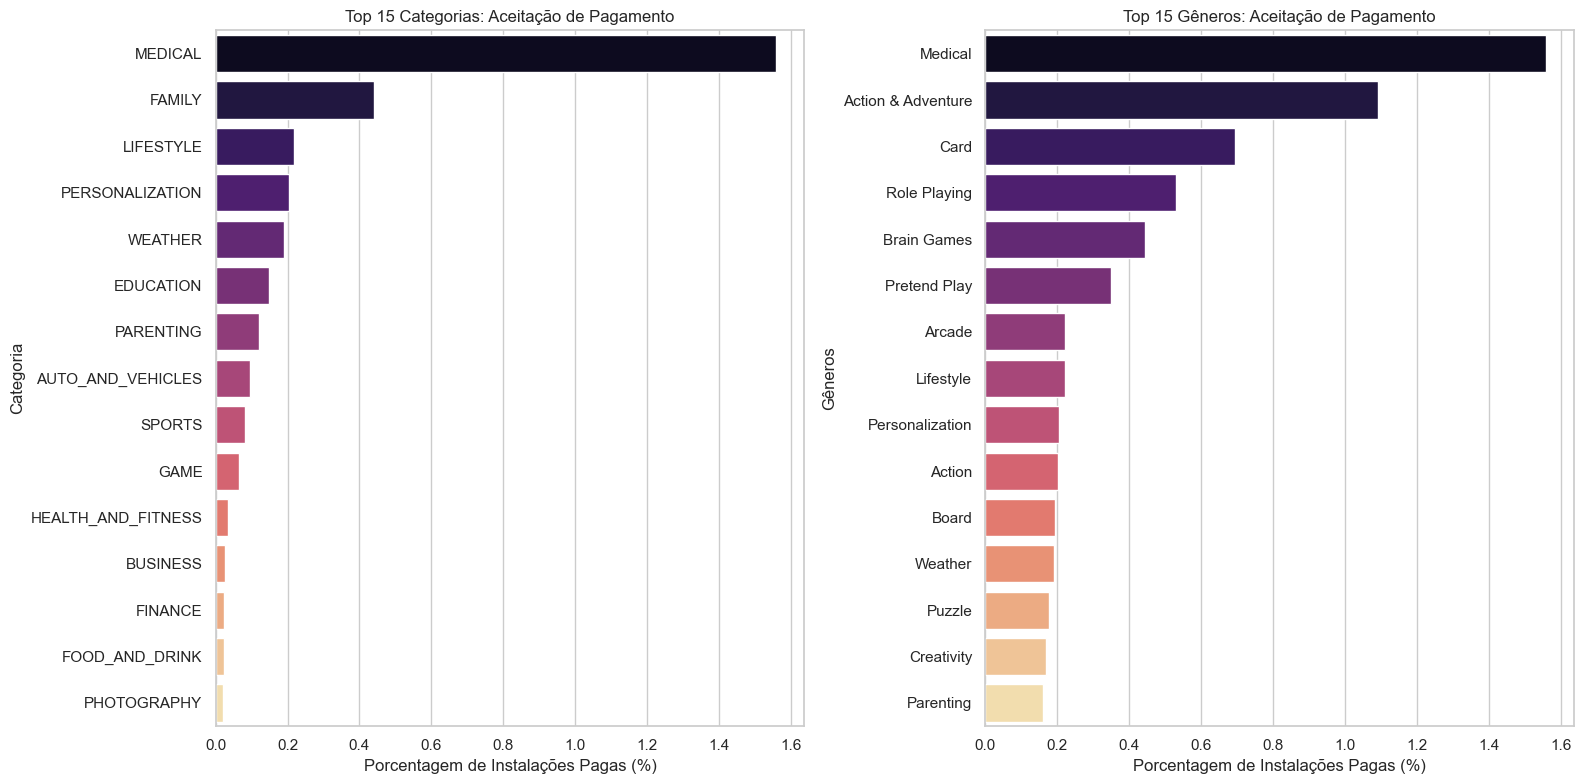

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8)) # Aumentei um pouco o figsize para caber melhor

pivot_cat = category_Type_data.reset_index().pivot(index='Category', columns='Type', values='Installs').fillna(0)
pivot_cat['Total'] = pivot_cat['Free'] + pivot_cat['Paid']
pivot_cat['Share_Paid'] = (pivot_cat['Paid'] / pivot_cat['Total']) * 100
top_cat = pivot_cat.sort_values('Share_Paid', ascending=False).head(15)

sns.barplot(x=top_cat['Share_Paid'], y=top_cat.index, palette='magma', ax=ax[0])
ax[0].set_title('Top 15 Categorias: Aceitação de Pagamento', fontsize=12) # Use set_title
ax[0].set_xlabel('Porcentagem de Instalações Pagas (%)')
ax[0].set_ylabel('Categoria')

pivot_gen = Genres_Type_data.reset_index().pivot(index='Genres', columns='Type', values='Installs').fillna(0)
pivot_gen['Total'] = pivot_gen['Free'] + pivot_gen['Paid']
pivot_gen['Share_Paid'] = (pivot_gen['Paid'] / pivot_gen['Total']) * 100
top_gen = pivot_gen.sort_values('Share_Paid', ascending=False).head(15)

sns.barplot(x=top_gen['Share_Paid'], y=top_gen.index, palette='magma', ax=ax[1])
ax[1].set_title('Top 15 Gêneros: Aceitação de Pagamento', fontsize=12) # Use set_title
ax[1].set_xlabel('Porcentagem de Instalações Pagas (%)')
ax[1].set_ylabel('Gêneros')

plt.tight_layout() 
plt.show() 

In [23]:
data["Content Rating"].value_counts()

Content Rating
Everyone           7503
Teen               1022
Mature 17+          411
Everyone 10+        399
Adults only 18+       3
Unrated               1
Name: count, dtype: int64

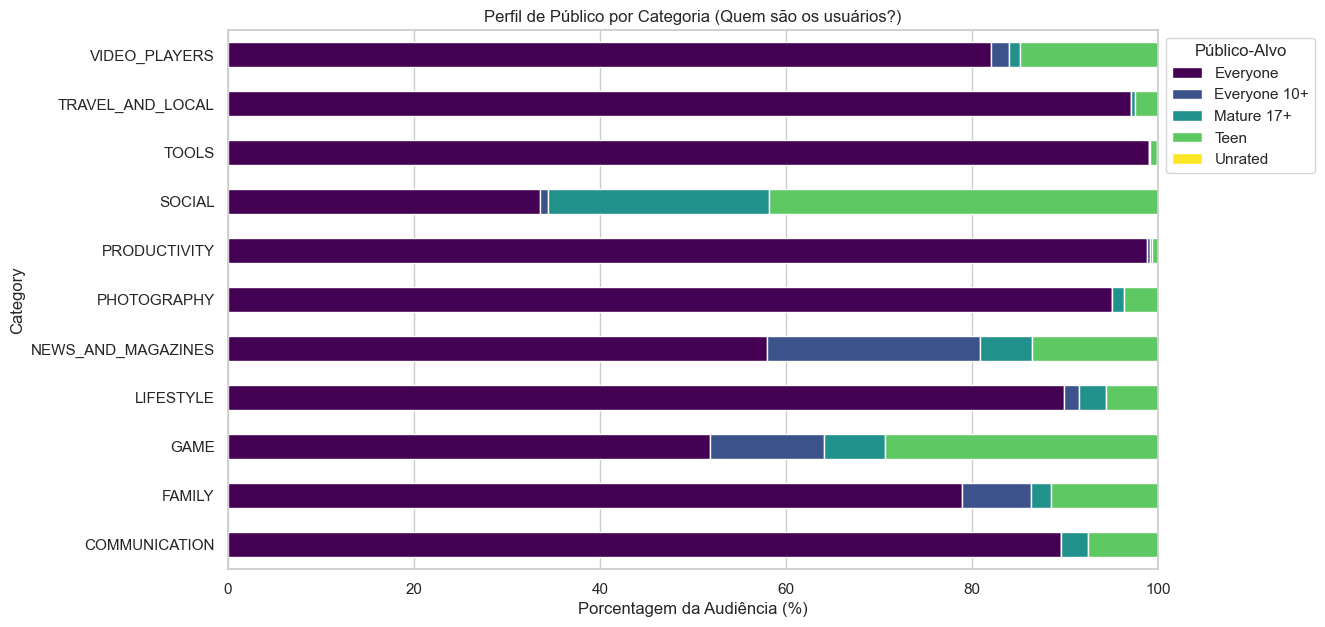

In [24]:
top_cats = data.groupby('Category')['Installs'].sum().nlargest(10).index
subset = data[(data['Category'].isin(top_cats)) | (data["Category"].isin(["LIFESTYLE","PRETEND PLAY"]))]

ct = pd.crosstab(subset['Category'], subset['Content Rating'], normalize='index') * 100

ct.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Perfil de Público por Categoria (Quem são os usuários?)')
plt.xlabel('Porcentagem da Audiência (%)')
plt.legend(title='Público-Alvo', bbox_to_anchor=(1, 1))
plt.show()